# Original exploration notebook (archived, unmodified)

This is the notebook as written during the thesis, kept for provenance. It is not
maintained: the layout script is duplicated once per configuration, and comments are
mixed Catalan, Spanish and English.

The maintained version of this work is the `probe_design` package, with the layouts
stored as data in `configs/`. See `01_probe_design.ipynb`.


**Probe lateral printed 1 TOP VIEW**

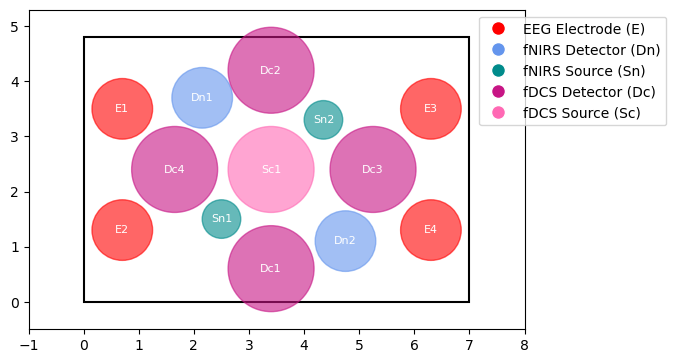

dist(Sc1,Sn2) = 1.309 cm
dist(Sc1,Sn1) = 1.273 cm
dist(Dn1,Sn1) = 2.228 cm
dist(Dn1,Sn2) = 2.236 cm
dist(Dn2,Sn1) = 2.285 cm
dist(Dn1,Sn2) = 2.236 cm
dist(Dc1,Sc1) = 1.800 cm
dist(Dc2,Sc1) = 1.800 cm
dist(Dc3,Sc1) = 1.850 cm
dist(Dc4,Sc1) = 1.750 cm
dist(Dc1,Dc2) = 3.600 cm

VALID fNIRS  (≥1.8 ≤3 cm, without obstacles betwwen)
Sn1–Dn1  :  2.23 cm
Sn1–Dn2  :  2.29 cm
Sn2–Dn1  :  2.24 cm
Sn2–Dn2  :  2.24 cm

VALID fDCS   (≥1.5 ≤2 cm, without obstacles between)
Sc1–Dc1  :  1.80 cm
Sc1–Dc2  :  1.80 cm
Sc1–Dc3  :  1.85 cm
Sc1–Dc4  :  1.75 cm



In [41]:
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# Diameters of each sensor (in cm)
D_ELECTRODE = 1.1
D_FNIRS_DETECTOR = 11/10
D_FNIRS_SOURCE = 7/10
D_FDCS_SOURCE = 15.6/10
D_FDCS_DETECTOR = 15.6/10

# Distance thresholds
MIN_THRESH_FNIRS = 1.8
MAX_THRESH_FNIRS = 3.0
MIN_THRESH_FDCS = 1.5
MAX_THRESH_FDCS = 2.0

# Rectangle size
width = 7
height = 4.8

# Sensor positions
electrodes = [[0.7, 3.5], [0.7, 1.3], [6.3, 3.5],[6.3, 1.3]]

# ---------- fNIRS ----------
sources_fnirs = [[2.5,1.5], [4.35,3.3]]
detectors_fnirs = [ [2.15, 3.7], [4.75,1.1]]  

# ---------- fDCS ----------
sources_fdcs  = [[3.4, 2.4]] 
detectors_fdcs = [[3.4, 0.6], [3.4, 4.2], [5.25, 2.4], [1.65, 2.4]] 


# -------------------------------------------------
#   Label → position
# -------------------------------------------------
label_to_position = {}
for i, p in enumerate(electrodes):        label_to_position[f'E{i+1}']  = p
for i, p in enumerate(detectors_fnirs):   label_to_position[f'Dn{i+1}'] = p
for i, p in enumerate(sources_fnirs):     label_to_position[f'Sn{i+1}'] = p
for i, p in enumerate(detectors_fdcs):    label_to_position[f'Dc{i+1}'] = p
for i, p in enumerate(sources_fdcs):      label_to_position[f'Sc{i+1}'] = p

# -------------------------------------------------
#   Distances (center-to-center)
# -------------------------------------------------
def compute_distance_between(a, b):
    x1, y1 = label_to_position[a]
    x2, y2 = label_to_position[b]
    return math.hypot(x1 - x2, y1 - y2)

def is_blocked(p1, p2, obstacles, buffer):
    """¿Is there some circle between p1-p2?
       obstacles = list of (x,y) of centers;
       buffer = additional margin"""
    x1, y1 = p1
    x2, y2 = p2
    for ox, oy in obstacles:
        if (ox, oy) == tuple(p1) or (ox, oy) == tuple(p2):
            continue
        # point to line distance
        num   = abs((y2 - y1) * ox - (x2 - x1) * oy + x2*y1 - y2*x1)
        denom = math.hypot(x2 - x1, y2 - y1)
        dist  = num / denom
        # projection in the segment
        t = ((ox - x1)*(x2 - x1) + (oy - y1)*(y2 - y1)) / (denom**2)
        if 0 < t < 1 and dist < buffer:
            return True
    return False

# -------------------------------------------------
#   INSPECTION
# -------------------------------------------------
def show_labels():
    print("LABEL  →  (x , y)")
    for lbl in sorted(label_to_position):
        print(f"{lbl:4s} → {tuple(round(v,3) for v in label_to_position[lbl])}")
    print()

def dist(a, b):
    d = compute_distance_between(a, b)
    print(f"dist({a},{b}) = {d:.3f} cm")
    return d

def report_pairs():
    all_pos = electrodes + sources_fnirs + detectors_fnirs + sources_fdcs + detectors_fdcs
    print("\nVALID fNIRS  (≥1.8 ≤3 cm, without obstacles betwwen)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sn')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dn')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FNIRS <= d <= MAX_THRESH_FNIRS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.3):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")

    print("\nVALID fDCS   (≥1.5 ≤2 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sc')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dc')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FDCS <= d <= MAX_THRESH_FDCS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.25):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")
    print()

# -------------------------------------------------
#   DRAWING
# -------------------------------------------------
def draw_configuration():
    fig, ax = plt.subplots()

    ax.add_patch(plt.Rectangle((0,0), width, height,
                               fill=False, edgecolor='black', linewidth=1.5))

    def draw_circle(pos, diam, color, label):
        c = plt.Circle(pos, diam/2, color=color, alpha=0.6)
        ax.add_patch(c)
        ax.text(pos[0], pos[1], label, ha='center', va='center',
                fontsize=8, color='white')

    # obstacle-list
    all_positions = electrodes + sources_fnirs + detectors_fnirs + \
                    sources_fdcs + detectors_fdcs

    # sensors draw
    for i,p in enumerate(electrodes):       draw_circle(p,D_ELECTRODE,'red',   f'E{i+1}')
    for i,p in enumerate(detectors_fnirs):  draw_circle(p,D_FNIRS_DETECTOR,'cornflowerblue', f'Dn{i+1}')
    for i,p in enumerate(sources_fnirs):    draw_circle(p,D_FNIRS_SOURCE,'darkcyan',  f'Sn{i+1}')
    for i,p in enumerate(detectors_fdcs):   draw_circle(p,D_FDCS_DETECTOR,'mediumvioletred' ,f'Dc{i+1}')
    for i,p in enumerate(sources_fdcs):     draw_circle(p,D_FDCS_SOURCE,'hotpink', f'Sc{i+1}')



    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

 

    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

    legend = [
        Line2D([0],[0], marker='o', color='w', label='EEG Electrode (E)', markerfacecolor='red',    markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Detector (Dn)', markerfacecolor='cornflowerblue',  markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Source (Sn)',   markerfacecolor='darkcyan',   markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Detector (Dc)',  markerfacecolor='mediumvioletred', markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Source (Sc)',    markerfacecolor='hotpink', markersize=10)
    ]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.3,1))
    plt.show()

# -------------------------------------------------
#   Execution
# -------------------------------------------------
draw_configuration() 
dist('Sc1','Sn2')

dist('Sc1','Sn1')
dist('Dn1','Sn1')
dist('Dn1','Sn2')
dist('Dn2','Sn1')

dist('Dn1','Sn2')
dist('Dc1','Sc1')
dist('Dc2','Sc1')
dist('Dc3','Sc1')
dist('Dc4','Sc1')
dist('Dc1','Dc2')
report_pairs()         # valid results

**Segona printed probe**

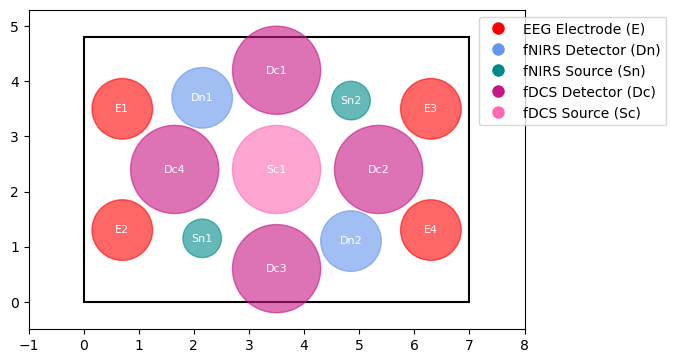

dist(Sc1,Sn2) = 1.840 cm
dist(Sc1,Sn1) = 1.840 cm
dist(Dn1,Sn1) = 2.550 cm
dist(Dn1,Sn2) = 2.700 cm
dist(Dn2,Sn1) = 2.700 cm
dist(Dn1,Sn2) = 2.700 cm
dist(Dc1,Sc1) = 1.800 cm
dist(Dc2,Sc1) = 1.850 cm
dist(Dc3,Sc1) = 1.800 cm
dist(Dc4,Sc1) = 1.850 cm
dist(Dc1,Dc2) = 2.581 cm

VALID fNIRS  (≥1.8 ≤3 cm, without obstacles betwwen)
Sn1–Dn1  :  2.55 cm
Sn1–Dn2  :  2.70 cm
Sn2–Dn1  :  2.70 cm
Sn2–Dn2  :  2.55 cm

VALID fDCS   (≥1.5 ≤2 cm, without obstacles between)
Sc1–Dc1  :  1.80 cm
Sc1–Dc2  :  1.85 cm
Sc1–Dc3  :  1.80 cm
Sc1–Dc4  :  1.85 cm



In [3]:
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# Diameters of each sensor (in cm)
D_ELECTRODE = 1.1
D_FNIRS_DETECTOR = 11/10
D_FNIRS_SOURCE = 7/10
D_FDCS_SOURCE = 16/10
D_FDCS_DETECTOR = 16/10

# Distance thresholds
MIN_THRESH_FNIRS = 1.8
MAX_THRESH_FNIRS = 3.0
MIN_THRESH_FDCS = 1.5
MAX_THRESH_FDCS = 2.0

# Rectangle size
width = 7
height = 4.8

# Sensor positions
electrodes = [[0.7, 3.5], [0.7, 1.3], [6.3, 3.5],[6.3, 1.3]]

# ---------- fNIRS ----------
sources_fnirs = [[2.15,1.15], [4.85,3.65]]
detectors_fnirs = [ [2.15, 3.7], [4.85,1.1]]  

# ---------- fDCS ----------
sources_fdcs  = [[3.5, 2.4]] 
detectors_fdcs = [[3.5, 4.2], [5.35, 2.4], [3.5, 0.6], [1.65, 2.4]]    



# -------------------------------------------------
#   Label → position
# -------------------------------------------------
label_to_position = {}
for i, p in enumerate(electrodes):        label_to_position[f'E{i+1}']  = p
for i, p in enumerate(detectors_fnirs):   label_to_position[f'Dn{i+1}'] = p
for i, p in enumerate(sources_fnirs):     label_to_position[f'Sn{i+1}'] = p
for i, p in enumerate(detectors_fdcs):    label_to_position[f'Dc{i+1}'] = p
for i, p in enumerate(sources_fdcs):      label_to_position[f'Sc{i+1}'] = p

# -------------------------------------------------
#   Distances (center-to-center)
# -------------------------------------------------
def compute_distance_between(a, b):
    x1, y1 = label_to_position[a]
    x2, y2 = label_to_position[b]
    return math.hypot(x1 - x2, y1 - y2)

def is_blocked(p1, p2, obstacles, buffer):
    """¿Is there some circle between p1-p2?
       obstacles = list of (x,y) of centers;
       buffer = additional margin"""
    x1, y1 = p1
    x2, y2 = p2
    for ox, oy in obstacles:
        if (ox, oy) == tuple(p1) or (ox, oy) == tuple(p2):
            continue
        # point to line distance
        num   = abs((y2 - y1) * ox - (x2 - x1) * oy + x2*y1 - y2*x1)
        denom = math.hypot(x2 - x1, y2 - y1)
        dist  = num / denom
        # projection in the segment
        t = ((ox - x1)*(x2 - x1) + (oy - y1)*(y2 - y1)) / (denom**2)
        if 0 < t < 1 and dist < buffer:
            return True
    return False

# -------------------------------------------------
#   INSPECTION
# -------------------------------------------------
def show_labels():
    print("LABEL  →  (x , y)")
    for lbl in sorted(label_to_position):
        print(f"{lbl:4s} → {tuple(round(v,3) for v in label_to_position[lbl])}")
    print()

def dist(a, b):
    d = compute_distance_between(a, b)
    print(f"dist({a},{b}) = {d:.3f} cm")
    return d

def report_pairs():
    all_pos = electrodes + sources_fnirs + detectors_fnirs + sources_fdcs + detectors_fdcs
    print("\nVALID fNIRS  (≥1.8 ≤3 cm, without obstacles betwwen)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sn')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dn')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FNIRS <= d <= MAX_THRESH_FNIRS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.3):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")

    print("\nVALID fDCS   (≥1.5 ≤2 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sc')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dc')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FDCS <= d <= MAX_THRESH_FDCS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.25):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")
    print()

# -------------------------------------------------
#   DRAWING
# -------------------------------------------------
def draw_configuration():
    fig, ax = plt.subplots()

    ax.add_patch(plt.Rectangle((0,0), width, height,
                               fill=False, edgecolor='black', linewidth=1.5))

    def draw_circle(pos, diam, color, label):
        c = plt.Circle(pos, diam/2, color=color, alpha=0.6)
        ax.add_patch(c)
        ax.text(pos[0], pos[1], label, ha='center', va='center',
                fontsize=8, color='white')

    # obstacle-list
    all_positions = electrodes + sources_fnirs + detectors_fnirs + \
                    sources_fdcs + detectors_fdcs

    # sensors draw
    for i,p in enumerate(electrodes):       draw_circle(p,D_ELECTRODE,'red',   f'E{i+1}')
    for i,p in enumerate(detectors_fnirs):  draw_circle(p,D_FNIRS_DETECTOR,'cornflowerblue', f'Dn{i+1}')
    for i,p in enumerate(sources_fnirs):    draw_circle(p,D_FNIRS_SOURCE,'darkcyan',  f'Sn{i+1}')
    for i,p in enumerate(detectors_fdcs):   draw_circle(p,D_FDCS_DETECTOR,'mediumvioletred' ,f'Dc{i+1}')
    for i,p in enumerate(sources_fdcs):     draw_circle(p,D_FDCS_SOURCE,'hotpink', f'Sc{i+1}')



    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

 

    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

    legend = [
        Line2D([0],[0], marker='o', color='w', label='EEG Electrode (E)', markerfacecolor='red',    markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Detector (Dn)', markerfacecolor='cornflowerblue',  markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Source (Sn)',   markerfacecolor='darkcyan',   markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Detector (Dc)',  markerfacecolor='mediumvioletred', markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Source (Sc)',    markerfacecolor='hotpink', markersize=10)
    ]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.3,1))
    plt.show()

# -------------------------------------------------
#   Execution
# -------------------------------------------------
draw_configuration() 
dist('Sc1','Sn2')

dist('Sc1','Sn1')
dist('Dn1','Sn1')
dist('Dn1','Sn2')
dist('Dn2','Sn1')

dist('Dn1','Sn2')
dist('Dc1','Sc1')
dist('Dc2','Sc1')
dist('Dc3','Sc1')
dist('Dc4','Sc1')
dist('Dc1','Dc2')
report_pairs()         # valid results

**Tercera i final probe printed**

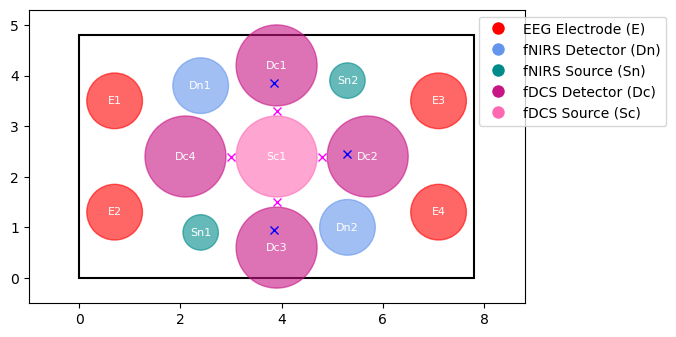

dist(Sc1,Sn2) = 2.052 cm
dist(Sc1,Sn1) = 2.121 cm
dist(Dn1,Sn1) = 2.900 cm
dist(Dn1,Sn2) = 2.902 cm
dist(Dn2,Sn1) = 2.902 cm
dist(Dn1,Sn2) = 2.902 cm
dist(Dc1,Sc1) = 1.800 cm
dist(Dc2,Sc1) = 1.800 cm
dist(Dc3,Sc1) = 1.800 cm
dist(Dc4,Sc1) = 1.800 cm
dist(Dc1,Dc2) = 2.546 cm

VALID fNIRS  (≥1.8 ≤3 cm, without obstacles betwwen)
Sn1–Dn2  :  2.90 cm
Sn2–Dn1  :  2.90 cm
Sn2–Dn2  :  2.90 cm

VALID fDCS   (≥1.5 ≤2 cm, without obstacles between)
Sc1–Dc1  :  1.80 cm
Sc1–Dc2  :  1.80 cm
Sc1–Dc3  :  1.80 cm
Sc1–Dc4  :  1.80 cm



In [59]:
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# Diameters of each sensor (in cm)
D_ELECTRODE = 1.1
D_FNIRS_DETECTOR = 11/10
D_FNIRS_SOURCE = 7/10
D_FDCS_SOURCE = 16/10
D_FDCS_DETECTOR = 16/10

# Distance thresholds
MIN_THRESH_FNIRS = 1.8
MAX_THRESH_FNIRS = 3.0
MIN_THRESH_FDCS = 1.5
MAX_THRESH_FDCS = 2.0

# Rectangle size
width = 7.8
height = 4.8
# Sensor positions
electrodes = [[0.7, 3.5], [0.7, 1.3], [7.1, 3.5],[7.1, 1.3]]

# ---------- fNIRS ----------
sources_fnirs = [[2.4,0.9], [5.3,3.9]]
detectors_fnirs = [ [2.4, 3.8], [5.3,1]]

# ---------- fDCS ----------
sources_fdcs  = [[3.9, 2.4]] 
detectors_fdcs = [[3.9, 4.2], [5.7, 2.4], [3.9, 0.6], [2.1, 2.4]]    



# -------------------------------------------------
#   Label → position
# -------------------------------------------------
label_to_position = {}
for i, p in enumerate(electrodes):        label_to_position[f'E{i+1}']  = p
for i, p in enumerate(detectors_fnirs):   label_to_position[f'Dn{i+1}'] = p
for i, p in enumerate(sources_fnirs):     label_to_position[f'Sn{i+1}'] = p
for i, p in enumerate(detectors_fdcs):    label_to_position[f'Dc{i+1}'] = p
for i, p in enumerate(sources_fdcs):      label_to_position[f'Sc{i+1}'] = p

# -------------------------------------------------
#   Distances (center-to-center)
# -------------------------------------------------
def compute_distance_between(a, b):
    x1, y1 = label_to_position[a]
    x2, y2 = label_to_position[b]
    return math.hypot(x1 - x2, y1 - y2)

def is_blocked(p1, p2, obstacles, buffer):
    """¿Is there some circle between p1-p2?
       obstacles = list of (x,y) of centers;
       buffer = additional margin"""
    x1, y1 = p1
    x2, y2 = p2
    for ox, oy in obstacles:
        if (ox, oy) == tuple(p1) or (ox, oy) == tuple(p2):
            continue
        # point to line distance
        num   = abs((y2 - y1) * ox - (x2 - x1) * oy + x2*y1 - y2*x1)
        denom = math.hypot(x2 - x1, y2 - y1)
        dist  = num / denom
        # projection in the segment
        t = ((ox - x1)*(x2 - x1) + (oy - y1)*(y2 - y1)) / (denom**2)
        if 0 < t < 1 and dist < buffer:
            return True
    return False

# -------------------------------------------------
#   INSPECTION
# -------------------------------------------------
def show_labels():
    print("LABEL  →  (x , y)")
    for lbl in sorted(label_to_position):
        print(f"{lbl:4s} → {tuple(round(v,3) for v in label_to_position[lbl])}")
    print()

def dist(a, b):
    d = compute_distance_between(a, b)
    print(f"dist({a},{b}) = {d:.3f} cm")
    return d

def report_pairs():
    all_pos = electrodes + sources_fnirs + detectors_fnirs + sources_fdcs + detectors_fdcs
    print("\nVALID fNIRS  (≥1.8 ≤3 cm, without obstacles betwwen)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sn')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dn')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FNIRS <= d <= MAX_THRESH_FNIRS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.3):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")

    print("\nVALID fDCS   (≥1.5 ≤2 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sc')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dc')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FDCS <= d <= MAX_THRESH_FDCS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.25):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")
    print()

# -------------------------------------------------
#   DRAWING
# -------------------------------------------------
def draw_configuration():
    fig, ax = plt.subplots()

    ax.add_patch(plt.Rectangle((0,0), width, height,
                               fill=False, edgecolor='black', linewidth=1.5))

    def draw_circle(pos, diam, color, label):
        c = plt.Circle(pos, diam/2, color=color, alpha=0.6)
        ax.add_patch(c)
        ax.text(pos[0], pos[1], label, ha='center', va='center',
                fontsize=8, color='white')

    # obstacle-list
    all_positions = electrodes + sources_fnirs + detectors_fnirs + \
                    sources_fdcs + detectors_fdcs

    # sensors draw
    for i,p in enumerate(electrodes):       draw_circle(p,D_ELECTRODE,'red',   f'E{i+1}')
    for i,p in enumerate(detectors_fnirs):  draw_circle(p,D_FNIRS_DETECTOR,'cornflowerblue', f'Dn{i+1}')
    for i,p in enumerate(sources_fnirs):    draw_circle(p,D_FNIRS_SOURCE,'darkcyan',  f'Sn{i+1}')
    for i,p in enumerate(detectors_fdcs):   draw_circle(p,D_FDCS_DETECTOR,'mediumvioletred' ,f'Dc{i+1}')
    for i,p in enumerate(sources_fdcs):     draw_circle(p,D_FDCS_SOURCE,'hotpink', f'Sc{i+1}')


    # valid pairs
    for d in detectors_fnirs:
        for s in sources_fnirs:
            dcc = math.hypot(d[0]-s[0], d[1]-s[1])
            if MIN_THRESH_FNIRS <= dcc <= MAX_THRESH_FNIRS and \
               not is_blocked(d, s, all_positions, 0.3):
                ax.plot((d[0]+s[0])/2, (d[1]+s[1])/2, 'x', color='blue')

    for d in detectors_fdcs:
        for s in sources_fdcs:
            dcc = math.hypot(d[0]-s[0], d[1]-s[1])
            if MIN_THRESH_FDCS <= dcc <= MAX_THRESH_FDCS and \
               not is_blocked(d, s, all_positions, 0.25):
                ax.plot((d[0]+s[0])/2, (d[1]+s[1])/2, 'x', color='magenta')

    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

 

    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

    legend = [
        Line2D([0],[0], marker='o', color='w', label='EEG Electrode (E)', markerfacecolor='red',    markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Detector (Dn)', markerfacecolor='cornflowerblue',  markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Source (Sn)',   markerfacecolor='darkcyan',   markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Detector (Dc)',  markerfacecolor='mediumvioletred', markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Source (Sc)',    markerfacecolor='hotpink', markersize=10)
    ]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.3,1))
    plt.show()

# -------------------------------------------------
#   Execution
# -------------------------------------------------
draw_configuration() 
dist('Sc1','Sn2')

dist('Sc1','Sn1')
dist('Dn1','Sn1')
dist('Dn1','Sn2')
dist('Dn2','Sn1')

dist('Dn1','Sn2')
dist('Dc1','Sc1')
dist('Dc2','Sc1')
dist('Dc3','Sc1')
dist('Dc4','Sc1')
dist('Dc1','Dc2')
report_pairs()         # valid results

**Occipital probe impresa**

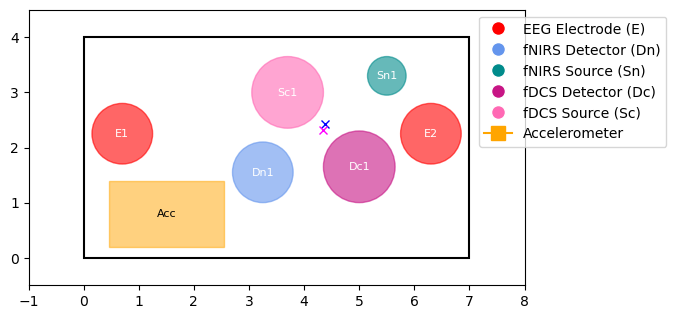

dist(Sc1,Dc1) = 1.874 cm
dist(Sn1,Dn1) = 2.850 cm

VALID fNIRS  (≥1.8 ≤3 cm, without obstacles between)
Sn1–Dn1  :  2.85 cm

VALID fDCS   (≥1.5 ≤2 cm, without obstacles between)
Sc1–Dc1  :  1.87 cm



In [78]:
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# Diameters of each sensor (in cm)
D_ELECTRODE = 1.1
D_FNIRS_DETECTOR = 11/10
D_FNIRS_SOURCE = 7/10
D_FDCS_SOURCE = 13/10
D_FDCS_DETECTOR = 13/10

# Distance thresholds
MIN_THRESH_FNIRS = 1.8
MAX_THRESH_FNIRS = 3.0
MIN_THRESH_FDCS = 1.5
MAX_THRESH_FDCS = 2.0
# Rectangle size
width = 7
height = 4

# Sensor positions
electrodes = [[0.7, 2.25], [6.3, 2.25]]

# ---------- fNIRS ----------
sources_fnirs = [[5.5, 3.3]]
detectors_fnirs =  [[3.25, 1.55]] 

# ---------- fDCS ----------
sources_fdcs  = [[3.7, 3]] 
detectors_fdcs = [[5, 1.65]] 


# -------------------------------------------------
#   Label → position
# -------------------------------------------------
label_to_position = {}
for i, p in enumerate(electrodes):        label_to_position[f'E{i+1}']  = p
for i, p in enumerate(detectors_fnirs):   label_to_position[f'Dn{i+1}'] = p
for i, p in enumerate(sources_fnirs):     label_to_position[f'Sn{i+1}'] = p
for i, p in enumerate(detectors_fdcs):    label_to_position[f'Dc{i+1}'] = p
for i, p in enumerate(sources_fdcs):      label_to_position[f'Sc{i+1}'] = p

# -------------------------------------------------
#   Distances (center-to-center)
# -------------------------------------------------
def compute_distance_between(a, b):
    x1, y1 = label_to_position[a]
    x2, y2 = label_to_position[b]
    return math.hypot(x1 - x2, y1 - y2)

def is_blocked(p1, p2, obstacles, buffer):
    """¿Is there some circle between p1-p2?
       obstacles = list of (x,y) of centers;
       buffer = additional margin"""
    x1, y1 = p1
    x2, y2 = p2
    for ox, oy in obstacles:
        if (ox, oy) == tuple(p1) or (ox, oy) == tuple(p2):
            continue
        num   = abs((y2 - y1) * ox - (x2 - x1) * oy + x2*y1 - y2*x1)
        denom = math.hypot(x2 - x1, y2 - y1)
        dist  = num / denom
        t = ((ox - x1)*(x2 - x1) + (oy - y1)*(y2 - y1)) / (denom**2)
        if 0 < t < 1 and dist < buffer:
            return True
    return False

# -------------------------------------------------
#   INSPECTION
# -------------------------------------------------
def show_labels():
    print("LABEL  →  (x , y)")
    for lbl in sorted(label_to_position):
        print(f"{lbl:4s} → {tuple(round(v,3) for v in label_to_position[lbl])}")
    print()

def dist(a, b):
    d = compute_distance_between(a, b)
    print(f"dist({a},{b}) = {d:.3f} cm")
    return d

def report_pairs():
    all_pos = electrodes + sources_fnirs + detectors_fnirs + sources_fdcs + detectors_fdcs
    print("\nVALID fNIRS  (≥1.8 ≤3 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sn')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dn')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FNIRS <= d <= MAX_THRESH_FNIRS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.3):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")

    print("\nVALID fDCS   (≥1.5 ≤2 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sc')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dc')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FDCS <= d <= MAX_THRESH_FDCS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.25):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")
    print()

# -------------------------------------------------
#   DRAWING
# -------------------------------------------------
def draw_configuration():
    fig, ax = plt.subplots()

    # marco general
    ax.add_patch(plt.Rectangle((0,0), width, height,
                               fill=False, edgecolor='black', linewidth=1.5))

    def draw_circle(pos, diam, color, label):
        c = plt.Circle(pos, diam/2, color=color, alpha=0.6)
        ax.add_patch(c)
        ax.text(pos[0], pos[1], label, ha='center', va='center',
                fontsize=8, color='white')

    def draw_rectangle(pos, width, height, color, label):
        bottom_left = (pos[0] - width/2, pos[1] - height/2)
        rect = plt.Rectangle(bottom_left, width, height, color=color, alpha=0.5)
        ax.add_patch(rect)
        ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=8, color='black')

    # obstacle-list
    all_positions = electrodes + sources_fnirs + detectors_fnirs + \
                    sources_fdcs + detectors_fdcs

    # sensors draw
    for i,p in enumerate(electrodes):       draw_circle(p,D_ELECTRODE,'red',   f'E{i+1}')
    for i,p in enumerate(detectors_fnirs):  draw_circle(p,D_FNIRS_DETECTOR,'cornflowerblue', f'Dn{i+1}')
    for i,p in enumerate(sources_fnirs):    draw_circle(p,D_FNIRS_SOURCE,'darkcyan',  f'Sn{i+1}')
    for i,p in enumerate(detectors_fdcs):   draw_circle(p,D_FDCS_DETECTOR,'mediumvioletred' ,f'Dc{i+1}')
    for i,p in enumerate(sources_fdcs):     draw_circle(p,D_FDCS_SOURCE,'hotpink', f'Sc{i+1}')
 
    # Añadir un rectángulo (puedes cambiar la posición y el tamaño)
    draw_rectangle((1.5, 0.8), 2.1, 1.2, 'orange', 'Acc')

    # valid pairs
    for d in detectors_fnirs:
        for s in sources_fnirs:
            dcc = math.hypot(d[0]-s[0], d[1]-s[1])
            if MIN_THRESH_FNIRS <= dcc <= MAX_THRESH_FNIRS and \
               not is_blocked(d, s, all_positions, 0.3):
                ax.plot((d[0]+s[0])/2, (d[1]+s[1])/2, 'x', color='blue')

    for d in detectors_fdcs:
        for s in sources_fdcs:
            dcc = math.hypot(d[0]-s[0], d[1]-s[1])
            if MIN_THRESH_FDCS <= dcc <= MAX_THRESH_FDCS and \
               not is_blocked(d, s, all_positions, 0.25):
                ax.plot((d[0]+s[0])/2, (d[1]+s[1])/2, 'x', color='magenta')

    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

    legend = [
        Line2D([0],[0], marker='o', color='w', label='EEG Electrode (E)', markerfacecolor='red',    markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Detector (Dn)', markerfacecolor='cornflowerblue',  markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Source (Sn)',   markerfacecolor='darkcyan',   markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Detector (Dc)',  markerfacecolor='mediumvioletred', markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Source (Sc)',    markerfacecolor='hotpink', markersize=10),
        Line2D([0],[0], marker='s', color='orange', label='Accelerometer', markerfacecolor='orange', markersize=10)
    ]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.3,1))
    plt.show()

# -------------------------------------------------
#   Execution
# -------------------------------------------------
draw_configuration() 
dist('Sc1','Dc1')
dist('Sn1','Dn1')
report_pairs()


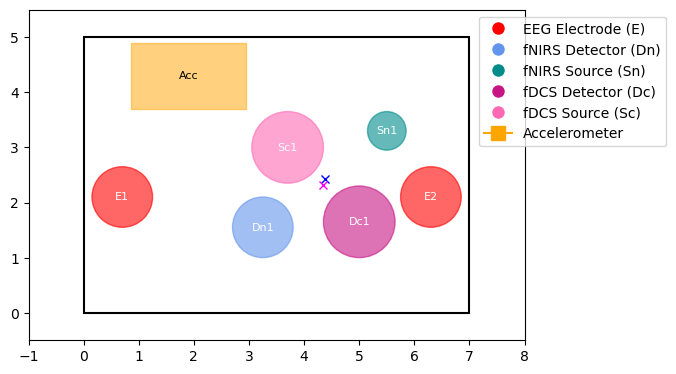

dist(Sc1,Dc1) = 1.874 cm
dist(Sn1,Dn1) = 2.850 cm

VALID fNIRS  (≥1.8 ≤3 cm, without obstacles between)
Sn1–Dn1  :  2.85 cm

VALID fDCS   (≥1.5 ≤2 cm, without obstacles between)
Sc1–Dc1  :  1.87 cm



In [85]:
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# Diameters of each sensor (in cm)
D_ELECTRODE = 1.1
D_FNIRS_DETECTOR = 11/10
D_FNIRS_SOURCE = 7/10
D_FDCS_SOURCE = 13/10
D_FDCS_DETECTOR = 13/10

# Distance thresholds
MIN_THRESH_FNIRS = 1.8
MAX_THRESH_FNIRS = 3.0
MIN_THRESH_FDCS = 1.5
MAX_THRESH_FDCS = 2.0
# Rectangle size
width = 7
height = 5

# Sensor positions
electrodes = [[0.7, 2.1], [6.3, 2.1]]

# ---------- fNIRS ----------
sources_fnirs = [[5.5, 3.3]]
detectors_fnirs =  [[3.25, 1.55]] 

# ---------- fDCS ----------
sources_fdcs  = [[3.7, 3]] 
detectors_fdcs = [[5, 1.65]] 


# -------------------------------------------------
#   Label → position
# -------------------------------------------------
label_to_position = {}
for i, p in enumerate(electrodes):        label_to_position[f'E{i+1}']  = p
for i, p in enumerate(detectors_fnirs):   label_to_position[f'Dn{i+1}'] = p
for i, p in enumerate(sources_fnirs):     label_to_position[f'Sn{i+1}'] = p
for i, p in enumerate(detectors_fdcs):    label_to_position[f'Dc{i+1}'] = p
for i, p in enumerate(sources_fdcs):      label_to_position[f'Sc{i+1}'] = p

# -------------------------------------------------
#   Distances (center-to-center)
# -------------------------------------------------
def compute_distance_between(a, b):
    x1, y1 = label_to_position[a]
    x2, y2 = label_to_position[b]
    return math.hypot(x1 - x2, y1 - y2)

def is_blocked(p1, p2, obstacles, buffer):
    """¿Is there some circle between p1-p2?
       obstacles = list of (x,y) of centers;
       buffer = additional margin"""
    x1, y1 = p1
    x2, y2 = p2
    for ox, oy in obstacles:
        if (ox, oy) == tuple(p1) or (ox, oy) == tuple(p2):
            continue
        num   = abs((y2 - y1) * ox - (x2 - x1) * oy + x2*y1 - y2*x1)
        denom = math.hypot(x2 - x1, y2 - y1)
        dist  = num / denom
        t = ((ox - x1)*(x2 - x1) + (oy - y1)*(y2 - y1)) / (denom**2)
        if 0 < t < 1 and dist < buffer:
            return True
    return False

# -------------------------------------------------
#   INSPECTION
# -------------------------------------------------
def show_labels():
    print("LABEL  →  (x , y)")
    for lbl in sorted(label_to_position):
        print(f"{lbl:4s} → {tuple(round(v,3) for v in label_to_position[lbl])}")
    print()

def dist(a, b):
    d = compute_distance_between(a, b)
    print(f"dist({a},{b}) = {d:.3f} cm")
    return d

def report_pairs():
    all_pos = electrodes + sources_fnirs + detectors_fnirs + sources_fdcs + detectors_fdcs
    print("\nVALID fNIRS  (≥1.8 ≤3 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sn')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dn')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FNIRS <= d <= MAX_THRESH_FNIRS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.3):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")

    print("\nVALID fDCS   (≥1.5 ≤2 cm, without obstacles between)")
    for s_lbl in [k for k in label_to_position if k.startswith('Sc')]:
        for d_lbl in [k for k in label_to_position if k.startswith('Dc')]:
            d = compute_distance_between(s_lbl, d_lbl)
            if MIN_THRESH_FDCS <= d <= MAX_THRESH_FDCS and \
               not is_blocked(label_to_position[s_lbl], label_to_position[d_lbl],
                              all_pos, buffer=0.25):
                print(f"{s_lbl}–{d_lbl}  :  {d:.2f} cm")
    print()

# -------------------------------------------------
#   DRAWING
# -------------------------------------------------
def draw_configuration():
    fig, ax = plt.subplots()

    # marco general
    ax.add_patch(plt.Rectangle((0,0), width, height,
                               fill=False, edgecolor='black', linewidth=1.5))

    def draw_circle(pos, diam, color, label):
        c = plt.Circle(pos, diam/2, color=color, alpha=0.6)
        ax.add_patch(c)
        ax.text(pos[0], pos[1], label, ha='center', va='center',
                fontsize=8, color='white')

    def draw_rectangle(pos, width, height, color, label):
        bottom_left = (pos[0] - width/2, pos[1] - height/2)
        rect = plt.Rectangle(bottom_left, width, height, color=color, alpha=0.5)
        ax.add_patch(rect)
        ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=8, color='black')

    # obstacle-list
    all_positions = electrodes + sources_fnirs + detectors_fnirs + \
                    sources_fdcs + detectors_fdcs

    # sensors draw
    for i,p in enumerate(electrodes):       draw_circle(p,D_ELECTRODE,'red',   f'E{i+1}')
    for i,p in enumerate(detectors_fnirs):  draw_circle(p,D_FNIRS_DETECTOR,'cornflowerblue', f'Dn{i+1}')
    for i,p in enumerate(sources_fnirs):    draw_circle(p,D_FNIRS_SOURCE,'darkcyan',  f'Sn{i+1}')
    for i,p in enumerate(detectors_fdcs):   draw_circle(p,D_FDCS_DETECTOR,'mediumvioletred' ,f'Dc{i+1}')
    for i,p in enumerate(sources_fdcs):     draw_circle(p,D_FDCS_SOURCE,'hotpink', f'Sc{i+1}')
 
    # Añadir un rectángulo (puedes cambiar la posición y el tamaño)
    draw_rectangle((1.9, 4.3), 2.1, 1.2, 'orange', 'Acc')

    # valid pairs
    for d in detectors_fnirs:
        for s in sources_fnirs:
            dcc = math.hypot(d[0]-s[0], d[1]-s[1])
            if MIN_THRESH_FNIRS <= dcc <= MAX_THRESH_FNIRS and \
               not is_blocked(d, s, all_positions, 0.3):
                ax.plot((d[0]+s[0])/2, (d[1]+s[1])/2, 'x', color='blue')

    for d in detectors_fdcs:
        for s in sources_fdcs:
            dcc = math.hypot(d[0]-s[0], d[1]-s[1])
            if MIN_THRESH_FDCS <= dcc <= MAX_THRESH_FDCS and \
               not is_blocked(d, s, all_positions, 0.25):
                ax.plot((d[0]+s[0])/2, (d[1]+s[1])/2, 'x', color='magenta')

    ax.set_aspect('equal','box')
    ax.set_xlim(-1, width+1); ax.set_ylim(-0.5, height+0.5)

    legend = [
        Line2D([0],[0], marker='o', color='w', label='EEG Electrode (E)', markerfacecolor='red',    markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Detector (Dn)', markerfacecolor='cornflowerblue',  markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fNIRS Source (Sn)',   markerfacecolor='darkcyan',   markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Detector (Dc)',  markerfacecolor='mediumvioletred', markersize=10),
        Line2D([0],[0], marker='o', color='w', label='fDCS Source (Sc)',    markerfacecolor='hotpink', markersize=10),
        Line2D([0],[0], marker='s', color='orange', label='Accelerometer', markerfacecolor='orange', markersize=10)
    ]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.3,1))
    plt.show()

# -------------------------------------------------
#   Execution
# -------------------------------------------------
draw_configuration() 
dist('Sc1','Dc1')
dist('Sn1','Dn1')
report_pairs()
